In [1]:
import h5py
import yaml
import numpy as np

with h5py.File("pixsplit_data/train/nparticles_resampled.h5", "r") as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")

barrelec: (3304287, 1)
charge: (3304287, 49)
last_phi: (3304287, 1)
last_theta: (3304287, 1)
layer: (3304287, 1)
mean_phi: (3304287, 1)
mean_theta: (3304287, 1)
nparticles: (3304287, 1)
pitches: (3304287, 7)


In [2]:
import h5py
import numpy as np
import yaml
import tensorflow as tf

# Using yaml 'mean' and 'std' values for normalization
# Z-Score Normalization / Standardization
with open("pixsplit_data/train/nparticles_resampled.yaml", "r") as f:
    meta = yaml.safe_load(f)

def load_split(folder_path):
    h5_path = f"{folder_path}/nparticles_resampled.h5"
    
    with h5py.File(h5_path, "r") as hf:
        # --- Y (Labels) ---
        y_int = (hf['nparticles'][:] - 1).astype(np.int32).flatten()
        y = tf.keras.utils.to_categorical(y_int, num_classes=3)

        # --- X1 (Charge Matrix) ---
        c_mean = np.array(meta['charge']['mean'], dtype=np.float32)
        c_std  = np.array(meta['charge']['std'], dtype=np.float32)
        X1 = (hf['charge'][:] - c_mean) / c_std

        # --- X2 (Context Vector) ---
        # Pitches
        p_mean = np.array(meta['pitches']['mean'], dtype=np.float32)
        p_std  = np.array(meta['pitches']['std'], dtype=np.float32)
        norm_pitches = (hf['pitches'][:] - p_mean) / p_std
        
        # Angles
        phi_mean = np.array(meta['mean_phi']['mean'], dtype=np.float32)
        phi_std  = np.array(meta['mean_phi']['std'], dtype=np.float32)
        norm_phi = (hf['mean_phi'][:] - phi_mean) / phi_std

        theta_mean = np.array(meta['mean_theta']['mean'], dtype=np.float32)
        theta_std  = np.array(meta['mean_theta']['std'], dtype=np.float32)
        norm_theta = (hf['mean_theta'][:] - theta_mean) / theta_std

        # Categorical Flags
        raw_layer = hf['layer'][:].astype(np.float32)
        raw_bec   = hf['barrelec'][:].astype(np.float32)

        # Stack into (N, 11) context vector
        X2 = np.hstack([norm_pitches, norm_phi, norm_theta, raw_layer, raw_bec])
        X = np.hstack([X1, X2])  
    return X, y

X_train, y_train = load_split("pixsplit_data/train")
X_val, y_val     = load_split("pixsplit_data/val")
X_test, y_test   = load_split("pixsplit_data/test")

print(f"Loaded {len(y_train)} training samples.")
print(f"Loaded {len(y_val)} validation samples.")

2026-04-07 17:52:09.656049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775577129.774747     902 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775577129.810626     902 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 17:52:10.135274: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loaded 3304287 training samples.
Loaded 413034 validation samples.


In [22]:
import numpy as np
import os

# Create a directory for our processed data
os.makedirs("processed_data", exist_ok=True)

# Save Training Set
np.save("processed_data/X_train.npy", X_train)
np.save("processed_data/y_train.npy", y_train)

# Save Validation Set
np.save("processed_data/X_val.npy", X_val)
np.save("processed_data/y_val.npy", y_val)

# Save Test Set
np.save("processed_data/X_test.npy", X_test)
np.save("processed_data/y_test.npy", y_test)

print("All files saved to /processed_data/")

All files saved to /processed_data/


In [1]:
import numpy as np
from hgq.utils.sugar import Dataset

X_train = np.load("processed_data/X_train.npy")
X_val = np.load("processed_data/X_val.npy")
X_test = np.load("processed_data/X_test.npy")
y_train = np.load("processed_data/y_train.npy")
y_val = np.load("processed_data/y_val.npy")
y_test = np.load("processed_data/y_test.npy")


dataset_train = Dataset(X_train, y_train, batch_size=33200, device='gpu:0')
dataset_val = Dataset(X_val, y_val, batch_size=33200, device='gpu:0')
dataset_test = Dataset(X_test, y_test, batch_size=33200, device='gpu:0')

2026-04-13 13:41:01.202378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776080461.351213    1035 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776080461.396787    1035 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 13:41:01.769898: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776080472.863487    1035 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 55

In [3]:
import os
import keras
from keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf
tf.random.set_seed(seed)

In [4]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy
from hgq.config import QuantizerConfig, QuantizerConfigScope
from hgq.layers import QDense, QSoftmax
from hgq.utils.sugar import FreeEBOPs, PBar, BetaScheduler, PieceWiseSchedule, EarlyStoppingWithEbopsThres

In [5]:
scope_weights = QuantizerConfigScope(
    place='all', 
    default_q_type='kbi', 
    heterogeneous_axis=None, 
    homogeneous_axis=(),
    overflow_mode='sat_sym'
)

scope_activations = QuantizerConfigScope(
    place='datalane', 
    default_q_type='kif', 
    heterogeneous_axis=None, 
    homogeneous_axis=(0, 1),
    overflow_mode='wrap'
)

#scope_layer = LayerConfigScope(enable_ebops=True, beta0=1e-5)

In [6]:
def build_model(beta0=1e-5):
    with scope_weights, scope_activations:

        model = keras.Sequential([
        
            keras.layers.Input(shape=(60,)), 
            
            QDense(128, beta0=beta0, activation='relu', name='dense_0'),
            QDense(64, beta0=beta0, activation='relu', name='dense_1'),
            QDense(32, beta0=beta0, activation='relu', name='dense_2'), 
            QDense(16, beta0=beta0, activation='relu', name='encoder_layer'),
            QDense(3, beta0=beta0, name='dense_out'),
        ])
    return model

model = build_model(beta0=0.5e-6) #0.5e-5
loss = keras.losses.CategoricalCrossentropy(from_logits=True)
opt = keras.optimizers.Adam() #5e-3

model.summary()
model.compile(opt, loss, metrics=['accuracy'], jit_compile=True, steps_per_execution=100)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_0 (QDense)                │ (None, 128)            │        31,238 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (QDense)                │ (None, 64)             │        33,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (QDense)                │ (None, 32)             │         8,326 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer (QDense)          │ (None, 16)             │         2,118 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_out (QDense)              │ (None, 3)              │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,922 (237.80 KB)

 Trainable params: 56,174 (219.43 KB)

 Non-trainable params: 18,748 (18.37 KB)

In [ ]:
import keras
import numpy as np
from math import cos, pi
from hgq.utils.sugar import BetaScheduler, Dataset, FreeEBOPs, ParetoFront, PBar, PieceWiseSchedule, EarlyStoppingWithEbopsThres
from keras.callbacks import LearningRateScheduler

OUTPUT_PATH = './model_pix/model_outputs'

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)
    print(f"Created new folder: {OUTPUT_PATH}")

def cosine_decay_restarts_schedule(
    initial_learning_rate: float, first_decay_steps: int, t_mul=1.0, m_mul=1.0, alpha=0.0, alpha_steps=0
):
    def schedule(global_step):
        n_cycle = 1
        cycle_step = global_step
        cycle_len = first_decay_steps
        while cycle_step >= cycle_len:
            cycle_step -= cycle_len
            cycle_len *= t_mul
            n_cycle += 1

        cycle_t = min(cycle_step / (cycle_len - alpha_steps), 1)
        lr = alpha + 0.5 * (initial_learning_rate - alpha) * (1 + cos(pi * cycle_t)) * m_mul ** max(n_cycle - 1, 0)
        return lr

    return schedule

pbar = PBar(
        'loss: {loss:.2f}/{val_loss:.2f} - acc: {accuracy:.4f}/{val_accuracy:.4f} - lr: {learning_rate:.2e} - beta: {beta:.1e}'
    )
ebops = FreeEBOPs()
pareto = ParetoFront(
        OUTPUT_PATH,
        ['val_accuracy', 'ebops'],
        [1, -1],
        fname_format='epoch={epoch}-val_acc={val_accuracy:.3f}-ebops={ebops}-val_loss={val_loss:.3f}.keras',
    )

beta_sched = BetaScheduler(PieceWiseSchedule([(0, 5e-7, 'constant'), (400, 5e-7, 'log'),(1000, 5e-6, 'log') (10000, 1e-3, 'constant')]))
lr_sched = LearningRateScheduler(
        cosine_decay_restarts_schedule(5e-3, 100, t_mul=1.0, m_mul=0.94, alpha=1e-6, alpha_steps=50)
    )

callbacks = [ebops, lr_sched, beta_sched, pbar, pareto]

<>:42: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
<>:42: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
/tmp/ipykernel_11138/3139331236.py:42: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  beta_sched = BetaScheduler(PieceWiseSchedule([(0, 5e-7, 'constant'), (400, 5e-7, 'log'),(1000, 5e-6, 'log') (10000, 1e-3, 'constant')]))
/tmp/ipykernel_11138/3139331236.py:42: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  beta_sched = BetaScheduler(PieceWiseSchedule([(0, 5e-7, 'constant'), (400, 5e-7, 'log'),(1000, 5e-6, 'log') (10000, 1e-3, 'constant')]))
/tmp/ipykernel_11138/3139331236.py:42: SyntaxWarning: 'tuple' object is not callable; perhaps you missed a comma?
  beta_sched = BetaScheduler(PieceWiseSchedule([(0, 5e-7, 'constant'), (400, 5e-7, 'log'),(1000, 5e-6, 'log') (10000, 1e-3, 'constant')]))
/tmp/ipykernel_11138/3139331236.py:42: SyntaxWarning: 'tuple' object is not c

TypeError: 'tuple' object is not callable

In [9]:
from tensorflow.python.client import device_lib
print([x.name for x in device_lib.list_local_devices() if 'GPU' in x.name])

['/device:GPU:0']


I0000 00:00:1775658013.810823   11138 gpu_device.cc:2022] Created device /device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
model.fit(dataset_train, epochs=10000, validation_data=dataset_val,callbacks=callbacks, verbose=0)

  0%|          | 0/100000 [00:00<?, ?epoch/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1775577221.598220    1462 service.cc:148] XLA service 0x70d8f0007ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775577221.598654    1462 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-07 17:53:41.844258: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775577222.737071    1462 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-07 17:53:44.111953: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3048', 444 bytes spill stores, 444 bytes spill loads

2026-04-07 17:53:47.740752: I external/local_xla/xla/

KeyboardInterrupt: 

In [ ]:
import os, glob, shutil

# 1. Get all Pareto saves
files = glob.glob("model_pix/model_outputs/*.keras")

# 2. Sort them by the EBOPs number in the filename
files.sort(key=lambda x: float(x.split('ebops=')[1].split('-')[0]))

# 3. The first one is the smallest!
smallest = files[0]
shutil.copy(smallest, "model_pix/best_compressed_model.keras")

print(f"Done! Picked {smallest}")

Done! Picked model_pix/model_outputs/epoch=660-val_acc=0.730-ebops=5024-val_loss=0.619.keras


In [7]:
from tensorflow.keras.models import load_model

model = load_model('model_pix/model_outputs/epoch=919-val_acc=0.742-ebops=6339-val_loss=0.590.keras')

In [8]:
score = model.evaluate(dataset_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.5915155410766602
Test accuracy: 0.7434690594673157


In [96]:
model.save('model_pix/model_pix.keras')

In [9]:
y_pix = model.predict(X_test)

12800/12908 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step

2026-04-13 13:46:05.079916: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


12908/12908 ━━━━━━━━━━━━━━━━━━━━ 11s 829us/step


<Figure size 800x600 with 0 Axes>

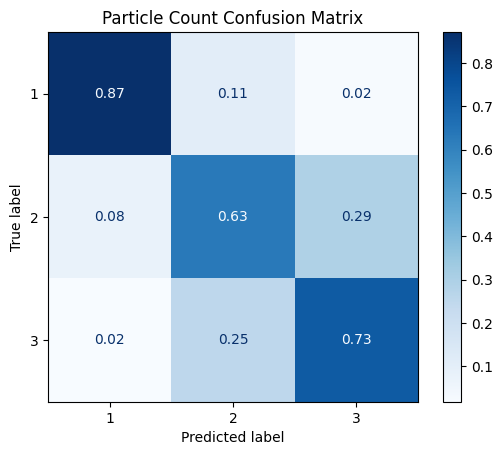

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(y_pix, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='.2f') # .2f shows 2 decimal places for percentages
plt.title('Particle Count Confusion Matrix')
plt.show()